In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.model_selection

In [2]:
metrics_list=dir(sklearn.model_selection)

In [3]:
print(metrics_list)

['BaseCrossValidator', 'GridSearchCV', 'GroupKFold', 'GroupShuffleSplit', 'KFold', 'LeaveOneGroupOut', 'LeaveOneOut', 'LeavePGroupsOut', 'LeavePOut', 'ParameterGrid', 'ParameterSampler', 'PredefinedSplit', 'RandomizedSearchCV', 'RepeatedKFold', 'RepeatedStratifiedKFold', 'ShuffleSplit', 'StratifiedKFold', 'StratifiedShuffleSplit', 'TimeSeriesSplit', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_search', '_split', '_validation', 'check_cv', 'cross_val_predict', 'cross_val_score', 'cross_validate', 'fit_grid_point', 'learning_curve', 'permutation_test_score', 'train_test_split', 'validation_curve']


In [4]:
import sklearn.tree
print(dir(sklearn.tree))

['BaseDecisionTree', 'DecisionTreeClassifier', 'DecisionTreeRegressor', 'ExtraTreeClassifier', 'ExtraTreeRegressor', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_classes', '_criterion', '_export', '_reingold_tilford', '_splitter', '_tree', '_utils', 'export_graphviz', 'export_text', 'plot_tree']


In [5]:
from sklearn.tree import DecisionTreeClassifier
print(dir(DecisionTreeClassifier))

['__abstractmethods__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_estimator_type', '_get_param_names', '_get_tags', '_more_tags', '_prune_tree', '_validate_X_predict', 'apply', 'cost_complexity_pruning_path', 'decision_path', 'feature_importances_', 'fit', 'get_depth', 'get_n_leaves', 'get_params', 'predict', 'predict_log_proba', 'predict_proba', 'score', 'set_params']


In [6]:
df=pd.read_csv("Downloads/student_digital_life.csv")

In [7]:
df.head()

,student_id,age,gender,study_hours_per_day,smartphone_usage_hours,social_media_hours,gaming_hours,streaming_hours,sleep_hours,exercise_hours,class_attendance_percent,assignment_completion_percent,caffeine_intake_cups,mental_health_status,parent_education_level,internet_quality,motivation_level,final_exam_score
0,1,21,Female,3.01,0.26,1.77,0.26,1.71,5.32,0.70,64.87,74.11,2,Good,Masters,Average,6.32,82.70
1,2,23,Female,5.84,8.02,3.30,0.96,0.00,5.99,1.99,85.38,80.68,3,Average,Masters,Poor,2.52,85.65
2,3,20,Female,7.80,10.13,0.00,2.23,2.54,6.36,1.82,76.15,79.69,2,Good,HighSchool,Poor,3.98,88.14
3,4,20,Female,0.00,1.15,1.32,4.19,0.27,7.86,0.18,84.41,79.07,0,Average,HighSchool,Average,4.77,54.81
4,5,24,Male,7.23,1.39,2.21,4.67,2.75,7.88,0.28,81.13,65.40,4,Good,HighSchool,Average,8.77,84.34


In [8]:
df.shape # 15k rows with 18 columns

(15000, 18)

In [9]:
#setting index
df=df.set_index('student_id',drop=True)

In [10]:
df.describe()

,age,study_hours_per_day,smartphone_usage_hours,social_media_hours,gaming_hours,streaming_hours,sleep_hours,exercise_hours,class_attendance_percent,assignment_completion_percent,caffeine_intake_cups,motivation_level,final_exam_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,21.024400,4.511505,5.503475,3.516837,2.241304,1.829245,6.997377,1.234827,84.631745,79.445435,1.504933,5.988216,80.344360
std,2.594299,1.981043,2.437488,1.767000,1.468125,1.132042,1.456868,0.827273,9.452752,13.918023,1.227060,1.949031,18.434455
min,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.500000,0.000000,44.960000,30.000000,0.000000,1.000000,2.630000
25%,19.000000,3.167500,3.830000,2.280000,1.110000,0.990000,5.970000,0.600000,78.180000,70.007500,1.000000,4.650000,68.730000
50%,21.000000,4.510000,5.480000,3.490000,2.175000,1.780000,6.990000,1.190000,84.895000,80.220000,1.000000,6.000000,83.745000
75%,23.000000,5.840000,7.150000,4.710000,3.260000,2.600000,8.030000,1.800000,91.650000,90.275000,2.000000,7.340000,97.810000
max,25.000000,11.780000,14.000000,9.000000,8.000000,6.000000,10.000000,4.660000,100.000000,100.000000,8.000000,10.000000,100.000000


In [11]:
#checking null values
df.isna().sum() #no null values

age                              0
gender                           0
study_hours_per_day              0
smartphone_usage_hours           0
social_media_hours               0
gaming_hours                     0
streaming_hours                  0
sleep_hours                      0
exercise_hours                   0
class_attendance_percent         0
assignment_completion_percent    0
caffeine_intake_cups             0
mental_health_status             0
parent_education_level           0
internet_quality                 0
motivation_level                 0
final_exam_score                 0
dtype: int64

In [12]:
#checking duplicate values
df.duplicated().sum() #no duplicates

0

In [13]:
# checking column names
df.columns

Index(['age', 'gender', 'study_hours_per_day', 'smartphone_usage_hours',
       'social_media_hours', 'gaming_hours', 'streaming_hours', 'sleep_hours',
       'exercise_hours', 'class_attendance_percent',
       'assignment_completion_percent', 'caffeine_intake_cups',
       'mental_health_status', 'parent_education_level', 'internet_quality',
       'motivation_level', 'final_exam_score'],
      dtype='object')

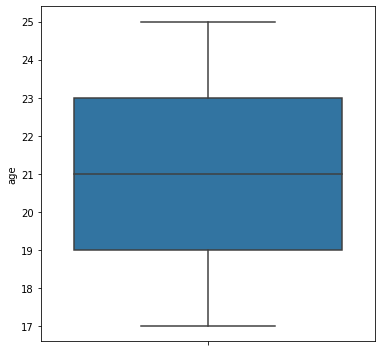

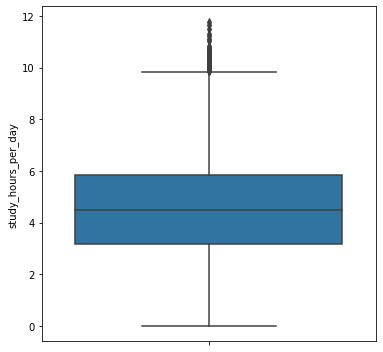

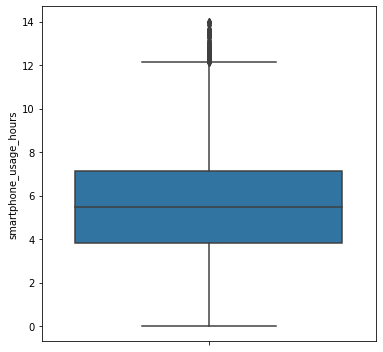

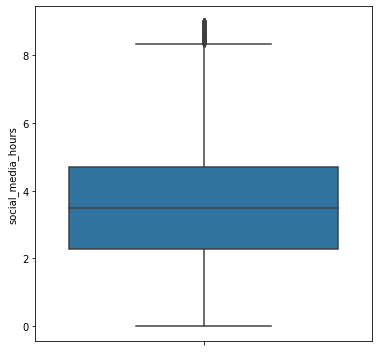

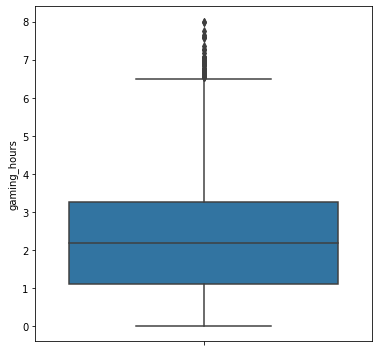

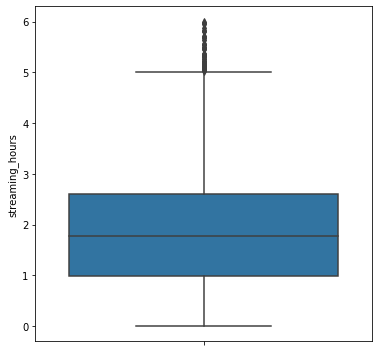

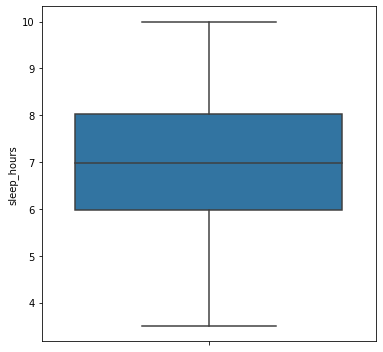

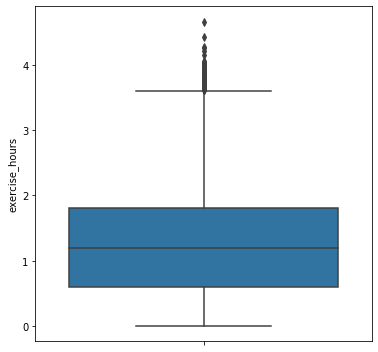

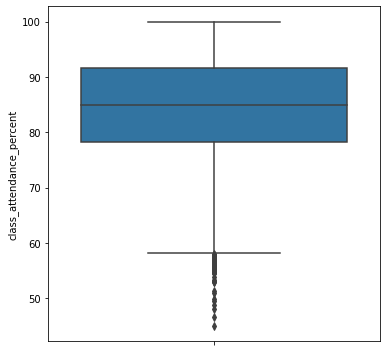

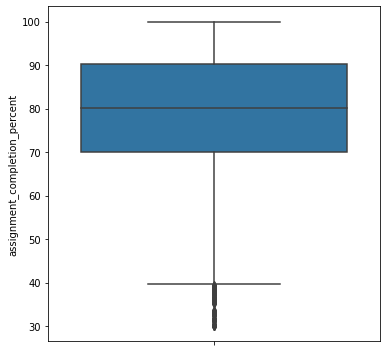

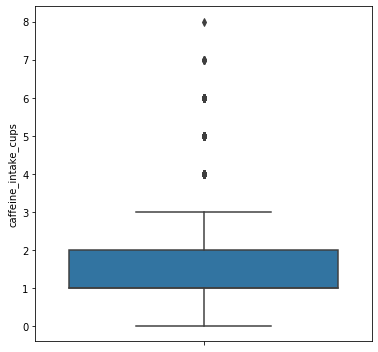

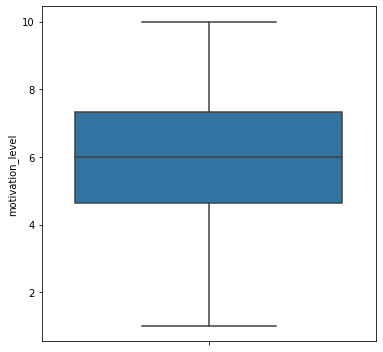

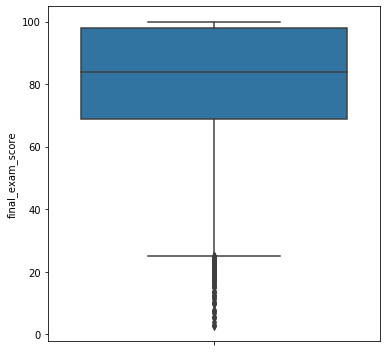

In [14]:
#checking outliers using boxplot
def boxplt(col):
    plt.figure(figsize=(15,5))
    plt.subplot(1, 3, 1)
    sns.boxplot(y=df[col])
    plt.xlabel=f"{col}"
    plt.ylabel='Frequency'
    plt.tight_layout()
    plt.show()
    return
for col in df.select_dtypes(include='number').columns:
    boxplt(col)
#there are outliers in few of the columns

In [15]:
#if we remove outliers we might loose data. Lets check skewness in the data
df.skew()

age                             -0.017726
study_hours_per_day              0.084209
smartphone_usage_hours           0.087424
social_media_hours               0.136395
gaming_hours                     0.357759
streaming_hours                  0.300085
sleep_hours                     -0.040627
exercise_hours                   0.379634
class_attendance_percent        -0.293069
assignment_completion_percent   -0.412013
caffeine_intake_cups             0.774990
motivation_level                -0.095154
final_exam_score                -0.875161
dtype: float64

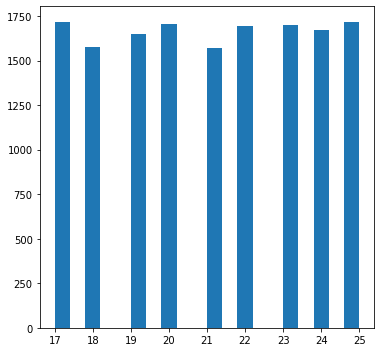

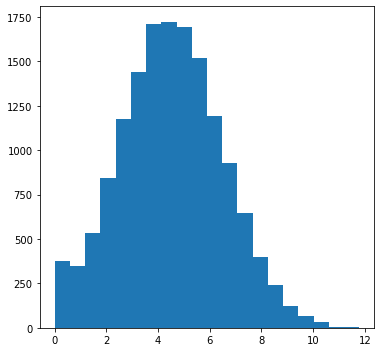

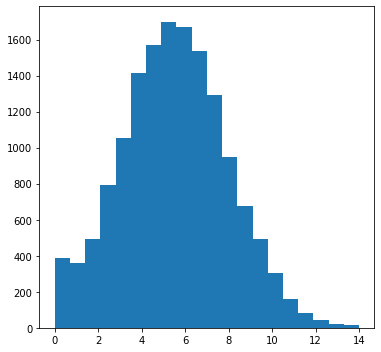

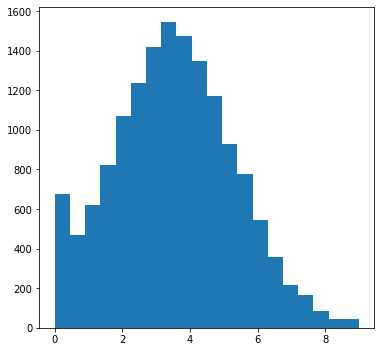

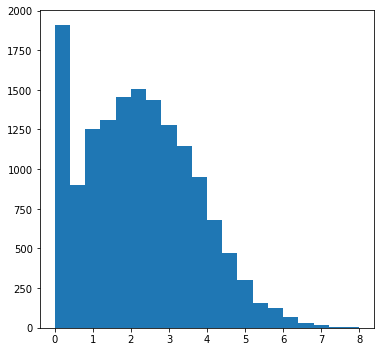

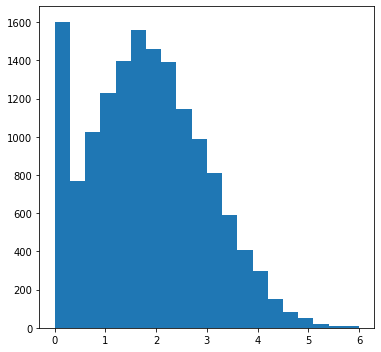

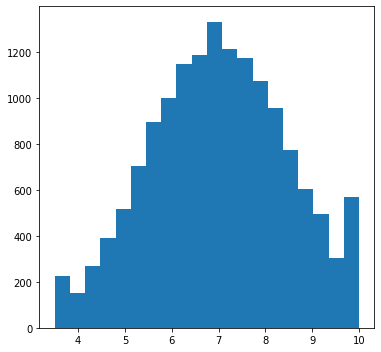

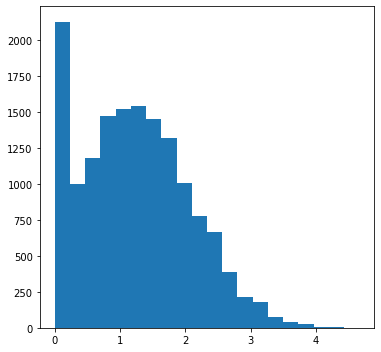

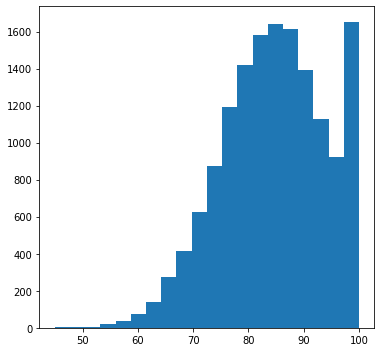

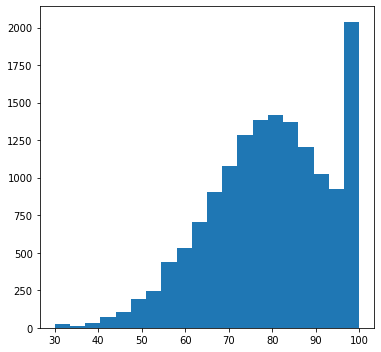

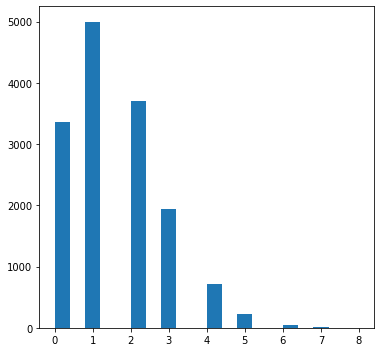

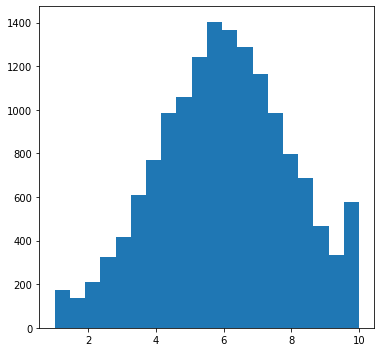

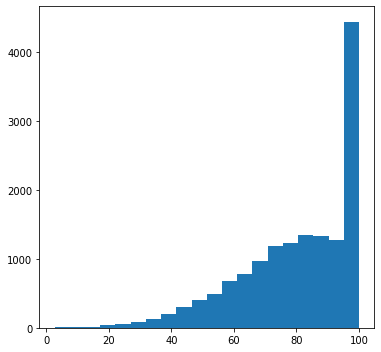

In [16]:
#lets plot histograms
def histplt(col):
    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.hist(df[col],bins=20)
    plt.xlabel=f"{col}"
    plt.tight_layout()
    plt.show()
    return
for col in df.select_dtypes(include='number').columns:
    histplt(col)

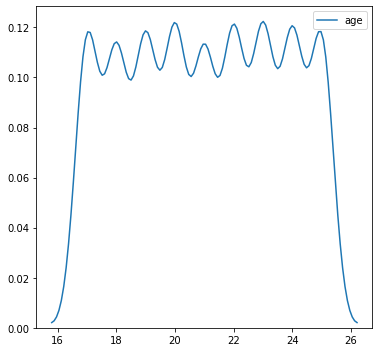

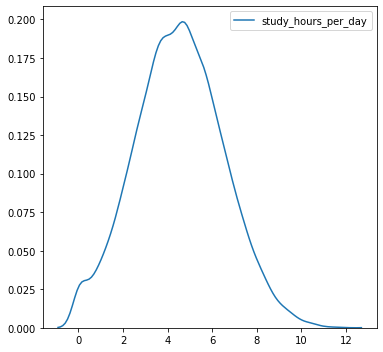

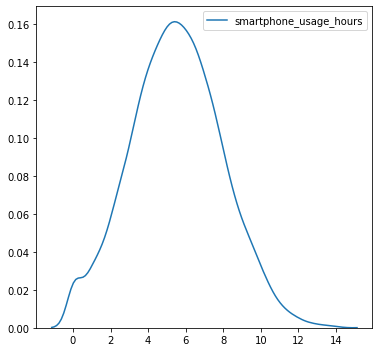

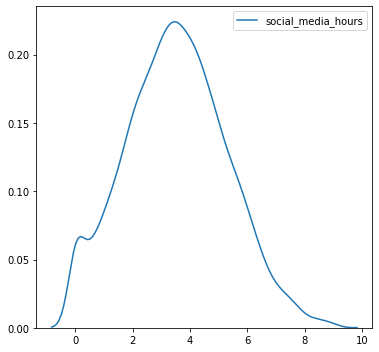

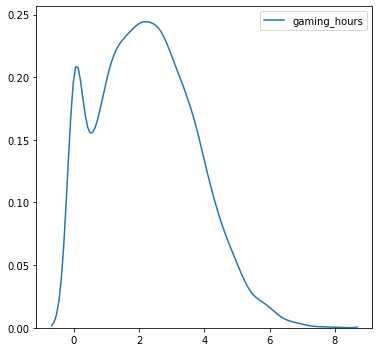

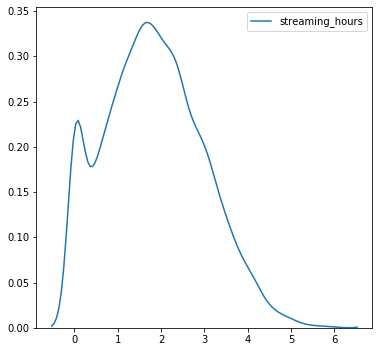

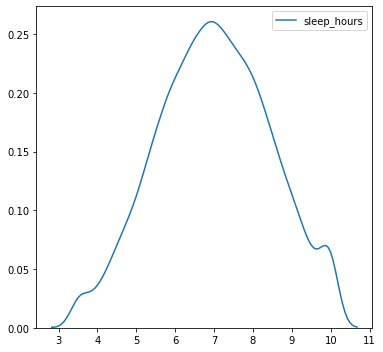

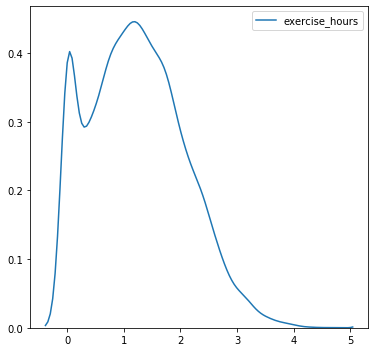

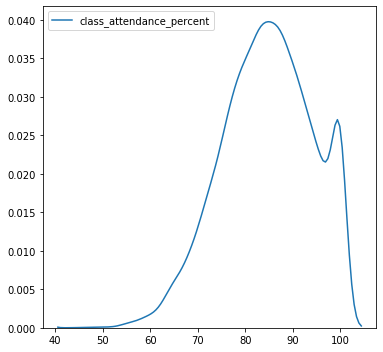

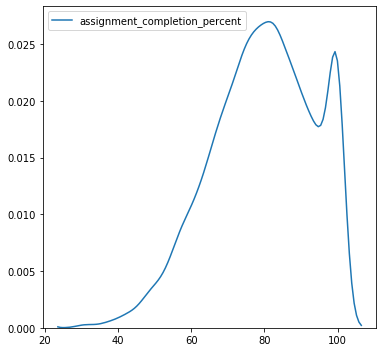

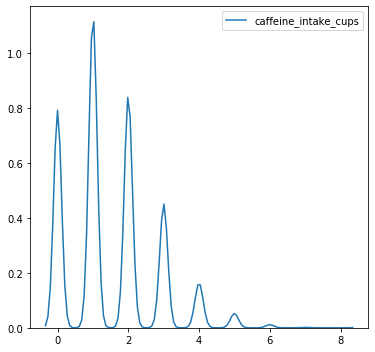

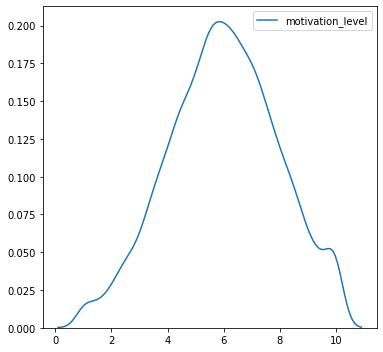

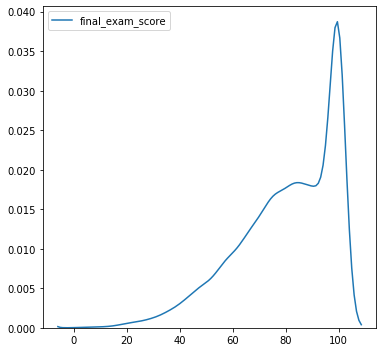

In [17]:
#lets plot kde to find distribution
def kdeeplt(col):
    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    sns.kdeplot(df[col])
    plt.xlabel=f"{col}"
    plt.tight_layout()
    plt.show()
    return
for col in df.select_dtypes(include='number').columns:
    kdeeplt(col)

# since the distibution is not normal we need to do scaling of the data but for decision tree or Random forest scaling is not required.

In [18]:
# since we have categorical variables we have to do encoding
from sklearn.preprocessing import LabelEncoder
lbe=LabelEncoder()
for col in df.select_dtypes(exclude='number').columns:
    df[col]=lbe.fit_transform(df[col])

In [19]:
for column in df.columns:
    unique_values = df[column].nunique()
    print(f"Unique values in column '{column}': {unique_values}")

Unique values in column 'age': 9
Unique values in column 'gender': 2
Unique values in column 'study_hours_per_day': 1008
Unique values in column 'smartphone_usage_hours': 1217
Unique values in column 'social_media_hours': 853
Unique values in column 'gaming_hours': 667
Unique values in column 'streaming_hours': 532
Unique values in column 'sleep_hours': 649
Unique values in column 'exercise_hours': 398
Unique values in column 'class_attendance_percent': 3581
Unique values in column 'assignment_completion_percent': 4673
Unique values in column 'caffeine_intake_cups': 9
Unique values in column 'mental_health_status': 3
Unique values in column 'parent_education_level': 4
Unique values in column 'internet_quality': 3
Unique values in column 'motivation_level': 894
Unique values in column 'final_exam_score': 5161


In [20]:
df.head()

,age,gender,study_hours_per_day,smartphone_usage_hours,social_media_hours,gaming_hours,streaming_hours,sleep_hours,exercise_hours,class_attendance_percent,assignment_completion_percent,caffeine_intake_cups,mental_health_status,parent_education_level,internet_quality,motivation_level,final_exam_score
student_id,,,,,,,,,,,,,,,,,
1,21,0,3.01,0.26,1.77,0.26,1.71,5.32,0.70,64.87,74.11,2,1,2,0,6.32,82.70
2,23,0,5.84,8.02,3.30,0.96,0.00,5.99,1.99,85.38,80.68,3,0,2,2,2.52,85.65
3,20,0,7.80,10.13,0.00,2.23,2.54,6.36,1.82,76.15,79.69,2,1,1,2,3.98,88.14
4,20,0,0.00,1.15,1.32,4.19,0.27,7.86,0.18,84.41,79.07,0,0,1,0,4.77,54.81
5,24,1,7.23,1.39,2.21,4.67,2.75,7.88,0.28,81.13,65.40,4,1,1,0,8.77,84.34


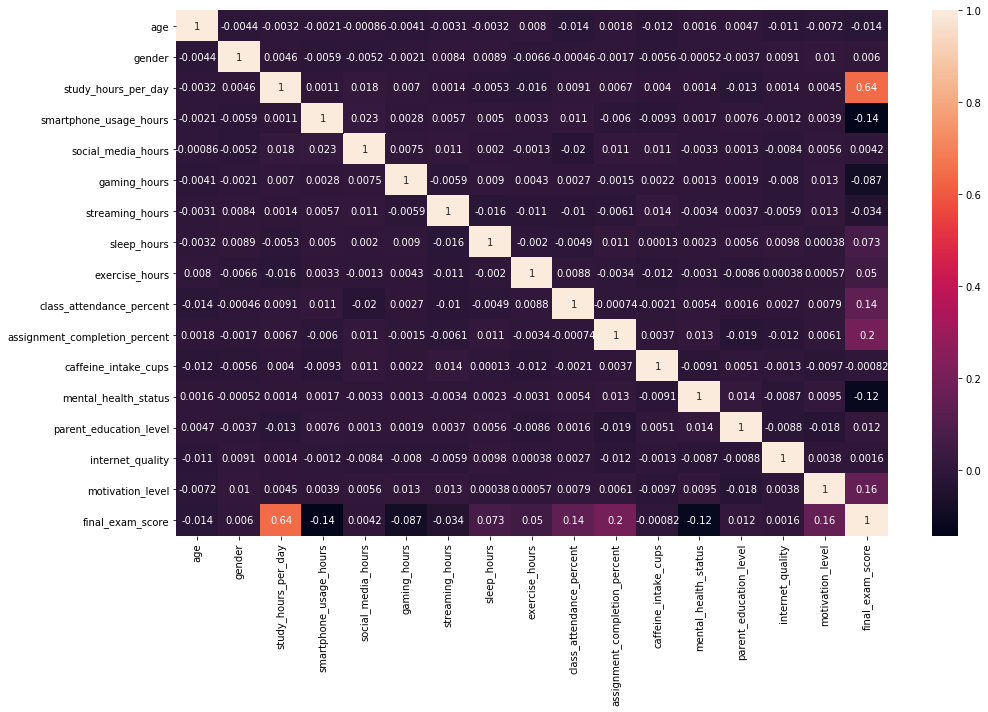

In [21]:
#plotting heatmap for correlation
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True)
plt.tight_layout()
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
X=df.drop('final_exam_score',axis=1)
y=df['final_exam_score']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(12000, 16) (3000, 16) (12000,) (3000,)


In [24]:
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor(random_state=100, max_depth=3, min_samples_leaf=5)
model.fit(X_train,y_train)

DecisionTreeRegressor(ccp_alpha=0.0, criterion='mse', max_depth=3,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=5, min_samples_split=2,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=100, splitter='best')

In [25]:
y_predict=model.predict(X_test)
print(y_predict)

[67.53836228 92.83279644 92.83279644 ... 92.83279644 67.53836228
 83.64525747]


In [26]:
diff=pd.DataFrame()
diff['Actual']=y_test.squeeze()
diff['Predict']=y_predict.squeeze()
diff['differ']=y_predict.squeeze()-y_test.squeeze()
print(diff['differ'])

student_id
11500    -9.971638
6476     -7.167204
13168     3.092796
863     -14.554743
5971     -7.167204
           ...    
6217     20.393425
3586      8.505257
10024     1.952796
14045   -13.941638
12966   -10.404743
Name: differ, Length: 3000, dtype: float64


In [27]:
#model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
MEA=mean_absolute_error(y_test,y_predict)
MSE=mean_squared_error(y_test,y_predict)
RMSE=np.sqrt(MSE)
R2=r2_score(y_test,y_predict)
print(f"MEA:{MEA}")
print(f"MSE:{MSE}")
print(f"RMSE:{RMSE}")
print(f"R2:{R2}")

MEA:10.665733885402743
MSE:178.04836457492127
RMSE:13.343476480097728
R2:0.48993795855912803


# Decision tree is not performing well as R2 is <0.5 and RMSE and MEA are pretty high

In [28]:
#lets try with random forest
import sklearn.ensemble
list1=dir(sklearn.ensemble)
print(list1)

['AdaBoostClassifier', 'AdaBoostRegressor', 'BaggingClassifier', 'BaggingRegressor', 'BaseEnsemble', 'ExtraTreesClassifier', 'ExtraTreesRegressor', 'GradientBoostingClassifier', 'GradientBoostingRegressor', 'IsolationForest', 'RandomForestClassifier', 'RandomForestRegressor', 'RandomTreesEmbedding', 'StackingClassifier', 'StackingRegressor', 'VotingClassifier', 'VotingRegressor', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_bagging', '_base', '_forest', '_gb', '_gb_losses', '_gradient_boosting', '_iforest', '_stacking', '_voting', '_weight_boosting', 'partial_dependence']


In [29]:
from sklearn.ensemble import RandomForestRegressor
model1=RandomForestRegressor()

In [30]:
model1.fit(X_train,y_train)

RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
                      max_depth=None, max_features='auto', max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=100, n_jobs=None, oob_score=False,
                      random_state=None, verbose=0, warm_start=False)

In [31]:
y_pred1=model1.predict(X_test)

In [32]:
y_diff=pd.DataFrame()
y_diff['Actual']=y_test.squeeze()
y_diff['Predict']=y_pred1.squeeze()
y_diff['diff']=y_pred1.squeeze()-y_test.squeeze()
print(y_diff)

            Actual  Predict     diff
student_id                          
11500        77.51  63.0873 -14.4227
6476        100.00  95.5065  -4.4935
13168        89.74  95.0525   5.3125
863          98.20  87.3906 -10.8094
5971        100.00  96.9604  -3.0396
...            ...      ...      ...
6217         53.01  51.5109  -1.4991
3586         75.14  87.4911  12.3511
10024        90.88  83.5136  -7.3664
14045        81.48  72.5600  -8.9200
12966        94.05  85.7916  -8.2584

[3000 rows x 3 columns]


In [33]:
#model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
MEA=mean_absolute_error(y_test,y_pred1)
MSE=mean_squared_error(y_test,y_pred1)
RMSE=np.sqrt(MSE)
R2=r2_score(y_test,y_pred1)
print(f"MEA:{MEA}")
print(f"MSE:{MSE}")
print(f"RMSE:{RMSE}")
print(f"R2:{R2}")

MEA:8.727165733333333
MSE:121.77185218089333
RMSE:11.035028417765554
R2:0.6511554618223596


# Random forest is performing better than Decision Tree but still the accuracy is around 0.65

In [34]:
# Lets try with linear models
df.head()

,age,gender,study_hours_per_day,smartphone_usage_hours,social_media_hours,gaming_hours,streaming_hours,sleep_hours,exercise_hours,class_attendance_percent,assignment_completion_percent,caffeine_intake_cups,mental_health_status,parent_education_level,internet_quality,motivation_level,final_exam_score
student_id,,,,,,,,,,,,,,,,,
1,21,0,3.01,0.26,1.77,0.26,1.71,5.32,0.70,64.87,74.11,2,1,2,0,6.32,82.70
2,23,0,5.84,8.02,3.30,0.96,0.00,5.99,1.99,85.38,80.68,3,0,2,2,2.52,85.65
3,20,0,7.80,10.13,0.00,2.23,2.54,6.36,1.82,76.15,79.69,2,1,1,2,3.98,88.14
4,20,0,0.00,1.15,1.32,4.19,0.27,7.86,0.18,84.41,79.07,0,0,1,0,4.77,54.81
5,24,1,7.23,1.39,2.21,4.67,2.75,7.88,0.28,81.13,65.40,4,1,1,0,8.77,84.34


In [35]:
# standardization before buidling model
from sklearn.model_selection import train_test_split
X1=df.drop('final_exam_score',axis=1)
y1=df['final_exam_score']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X1,y1,test_size=0.2,random_state=42)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [36]:
from sklearn.linear_model import LinearRegression
model2=LinearRegression()

In [37]:
model2.fit(X_train_scaled,y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [38]:
y_pred2=model2.predict(X_test_scaled)

In [39]:
y_predict2=pd.DataFrame()
y_predict2['Actual']=y_test.squeeze()
y_predict2['pred']=y_pred2.squeeze()
y_predict2['diff']=y_pred2.squeeze()-y_test.squeeze()
print(y_predict2)

            Actual        pred       diff
student_id                               
11500        77.51   69.092376  -8.417624
6476        100.00  102.640334   2.640334
13168        89.74   97.769273   8.029273
863          98.20   82.097200 -16.102800
5971        100.00   96.256908  -3.743092
...            ...         ...        ...
6217         53.01   71.263041  18.253041
3586         75.14   76.337526   1.197526
10024        90.88   82.252533  -8.627467
14045        81.48   77.452502  -4.027498
12966        94.05   84.220090  -9.829910

[3000 rows x 3 columns]


In [40]:
#model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
MEA=mean_absolute_error(y_test,y_pred2)
MSE=mean_squared_error(y_test,y_pred2)
RMSE=np.sqrt(MSE)
R2=r2_score(y_test,y_pred2)
print(f"MEA:{MEA}")
print(f"MSE:{MSE}")
print(f"RMSE:{RMSE}")
print(f"R2:{R2}")

MEA:10.062699300332223
MSE:159.68263634051544
RMSE:12.636559513590534
R2:0.5425509710861118


# LinearRegression is performing better than Decision Tree but not better than Random Forest.

In [41]:
# lets compare with other models
import sklearn.ensemble
print(dir(sklearn.ensemble))

['AdaBoostClassifier', 'AdaBoostRegressor', 'BaggingClassifier', 'BaggingRegressor', 'BaseEnsemble', 'ExtraTreesClassifier', 'ExtraTreesRegressor', 'GradientBoostingClassifier', 'GradientBoostingRegressor', 'IsolationForest', 'RandomForestClassifier', 'RandomForestRegressor', 'RandomTreesEmbedding', 'StackingClassifier', 'StackingRegressor', 'VotingClassifier', 'VotingRegressor', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_bagging', '_base', '_forest', '_gb', '_gb_losses', '_gradient_boosting', '_iforest', '_stacking', '_voting', '_weight_boosting', 'partial_dependence']


In [42]:
from sklearn.ensemble import AdaBoostRegressor,GradientBoostingRegressor
abr=AdaBoostRegressor()
gbr=GradientBoostingRegressor()

In [43]:
abr.fit(X_train_scaled,y_train)
y_abr=abr.predict(X_test_scaled)

In [46]:
y_abr_df=pd.DataFrame()
y_abr_df['Actual']=y_test.squeeze()
y_abr_df['Predict']=y_abr.squeeze()
y_abr_df['diff']=y_abr.squeeze()-y_test.squeeze()
print(y_abr_df)

            Actual    Predict       diff
student_id                              
11500        77.51  66.133301 -11.376699
6476        100.00  81.260807 -18.739193
13168        89.74  84.532895  -5.207105
863          98.20  80.555702 -17.644298
5971        100.00  85.226837 -14.773163
...            ...        ...        ...
6217         53.01  64.363710  11.353710
3586         75.14  80.277065   5.137065
10024        90.88  80.277065 -10.602935
14045        81.48  68.714106 -12.765894
12966        94.05  78.684286 -15.365714

[3000 rows x 3 columns]


In [47]:
#model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
MEA=mean_absolute_error(y_test,y_abr)
MSE=mean_squared_error(y_test,y_abr)
RMSE=np.sqrt(MSE)
R2=r2_score(y_test,y_abr)
print(f"MEA:{MEA}")
print(f"MSE:{MSE}")
print(f"RMSE:{RMSE}")
print(f"R2:{R2}")

MEA:11.592245730412571
MSE:185.25774519769934
RMSE:13.61094211278923
R2:0.4692849668466932


# Adaboostregressor is not performing well

In [49]:
gbr.fit(X_train_scaled,y_train)
y_gbr=gbr.predict(X_test_scaled)

In [50]:
y_gbr_df=pd.DataFrame()
y_gbr_df['Actual']=y_test.squeeze()
y_gbr_df['Predict']=y_gbr.squeeze()
y_gbr_df['diff']=y_gbr.squeeze()-y_test.squeeze()
print(y_gbr_df)

            Actual     Predict       diff
student_id                               
11500        77.51   61.265979 -16.244021
6476        100.00   95.676649  -4.323351
13168        89.74   92.173075   2.433075
863          98.20   85.637735 -12.562265
5971        100.00  100.519444   0.519444
...            ...         ...        ...
6217         53.01   58.476940   5.466940
3586         75.14   84.911196   9.771196
10024        90.88   84.393070  -6.486930
14045        81.48   74.093085  -7.386915
12966        94.05   86.997375  -7.052625

[3000 rows x 3 columns]


In [51]:
#model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
MEA=mean_absolute_error(y_test,y_gbr)
MSE=mean_squared_error(y_test,y_gbr)
RMSE=np.sqrt(MSE)
R2=r2_score(y_test,y_gbr)
print(f"MEA:{MEA}")
print(f"MSE:{MSE}")
print(f"RMSE:{RMSE}")
print(f"R2:{R2}")

MEA:8.389942814079964
MSE:112.1178128553315
RMSE:10.588569915495269
R2:0.6788117619422885


# Gradiant Boosting Regressor is performing better than all other models

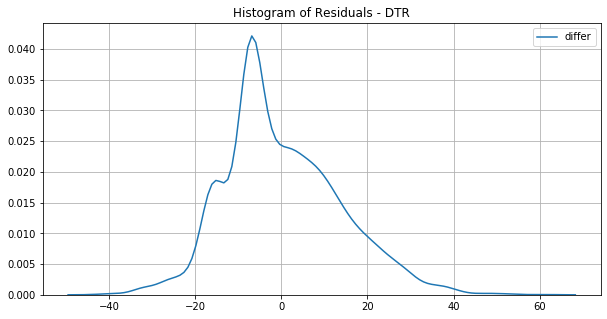

In [55]:
# Lets check for normality of residuals using Histogram or Q-Q plots
# Histogram: Should resemble a bell curve if residuals are normally distributed.
plt.figure(figsize=(10, 5))
sns.kdeplot(diff['differ'])
plt.title('Histogram of Residuals - DTR')
plt.grid(True)
plt.show()

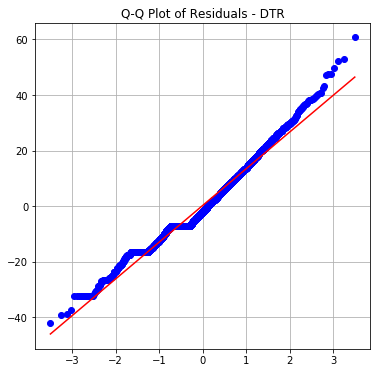

In [54]:
# Q-Q plot: Points should lie roughly on the diagonal line. Major deviations suggest non-normality.
# Q-Q plot of residuals
import scipy.stats as stats
plt.figure(figsize=(6, 6))
stats.probplot(diff['differ'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals - DTR')
plt.grid(True)
plt.show()

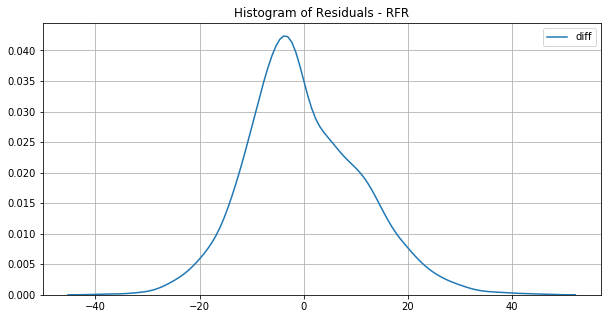

In [56]:
plt.figure(figsize=(10, 5))
sns.kdeplot(y_diff['diff'])
plt.title('Histogram of Residuals - RFR')
plt.grid(True)
plt.show()

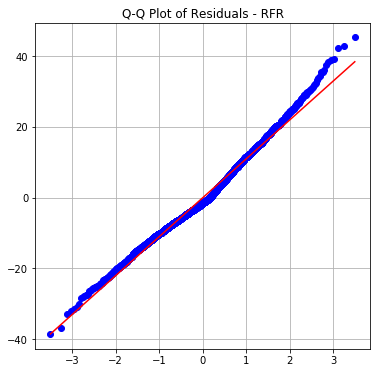

In [57]:
import scipy.stats as stats
plt.figure(figsize=(6, 6))
stats.probplot(y_diff['diff'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals - RFR')
plt.grid(True)
plt.show()

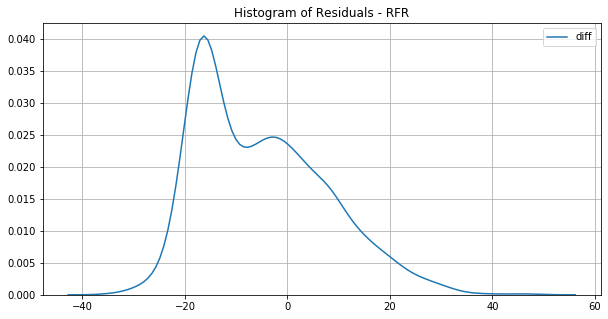

In [58]:
plt.figure(figsize=(10, 5))
sns.kdeplot(y_abr_df['diff'])
plt.title('Histogram of Residuals - ABR')
plt.grid(True)
plt.show()

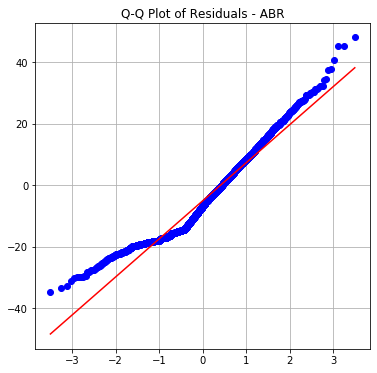

In [59]:
import scipy.stats as stats
plt.figure(figsize=(6, 6))
stats.probplot(y_abr_df['diff'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals - ABR')
plt.grid(True)
plt.show()

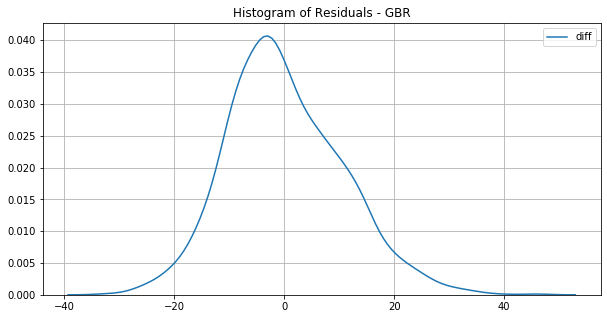

In [60]:
plt.figure(figsize=(10, 5))
sns.kdeplot(y_gbr_df['diff'])
plt.title('Histogram of Residuals - GBR')
plt.grid(True)
plt.show()

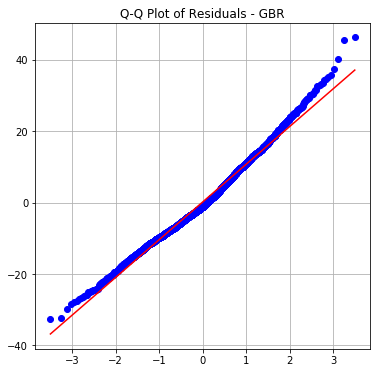

In [61]:
import scipy.stats as stats
plt.figure(figsize=(6, 6))
stats.probplot(y_gbr_df['diff'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals - GBR')
plt.grid(True)
plt.show()

#   GradientBoost Regressor is performing best among all the other models